# LangChain RAG Walkthrough with ChromaDB

This notebook demonstrates a complete Retrieval-Augmented Generation (RAG) implementation using:
- **LangChain** for orchestration
- **ChromaDB** as the vector store (ephemeral, no background processes)
- **Flexible LLM support** for OpenAI, Gemini, or Ollama
- **Document chunking** and **embedding** workflows
- **Similarity-based retrieval**

## Overview
1. Setup and Dependencies
2. Document Loading and Chunking
3. Embedding Generation
4. Vector Store Creation (ChromaDB)
5. Similarity Retrieval
6. LLM Integration (OpenAI/Gemini/Ollama)
7. Complete RAG Pipeline

In [1]:
# Install required packages
!pip install -qU langchain langchain-community chromadb pypdf langchain-ollama langgraph wikipedia

In [2]:
# Import required libraries

from typing import List
from dotenv import load_dotenv

from langchain.chat_models.base import init_chat_model

load_dotenv()  # Load environment variables from .env file

False

## 1. Document Preparation

Langchain has a plethora of ways to load documents, these include but are not limited to:
- Web loaders for scraping websites
- PDF loaders
- CSV loaders
- Social Platform scrapers
- Messaging service loaders

More information about the available document loaders can be found in the [Document Loaders](https://python.langchain.com/docs/integrations/document_loaders/) section of the langchain documentation. 

For the purpose of this demonstration though we will use the RSECon schedule which can be obtained from the [RSECon25 Programme](https://virtual.oxfordabstracts.com/event/75166/program). This will be downloaded as a PDF and loaded in using LangChain's `PyPDFLoader`.


In [3]:
# Create/get sample documents for demonstration
from langchain_community.document_loaders import PyPDFLoader

file_path = "./rsecon_schedule.pdf"

loader = PyPDFLoader(file_path)
docs = loader.load()
print(f"Loaded {len(docs)} documents from {file_path}")

Loaded 11 documents from ./rsecon_schedule.pdf


## Accessing content

PyPDF loads the PDF as a list of `Document` objects, one per page. Different loaders have different strategies for how they parse the input, but all of them should output `Document` object(s).

The raw text content of a `Document` can be accessed using the `.page_content` method.

In [4]:
print(docs[0].page_content)

RSECon25
Schedule
Monday, 8 September, 2025
09:30-16:30OC1.09
Back to Fortran Future 2 Satellite Event
Satellite Event
https://rsecon25.society-rse.org/back-to-fortran-future-2/
12:00-17:00OC1.01
RSE Leaders
Satellite Event
Satellite event – RSE leaders and aspiring leaders meeting
https://rsecon25.society-rse.org/leaders-meeting/
14:00-17:00The Oculus Atrium
Early Registration
17:00-18:00
NOTE: PROGRAMME SIGNIFICANTLY UPDATED 12/8
18:00-23:00Rootes Restaurant
Welcome social
Social
18:00-18:30
Meet & Greet: Settle In
Social
New to the conference, attending solo, or just want to meet new people? Join us for this relaxed session before the ﬁrst social kicks oﬀ. A chance to
connect with others in a welcoming space – open to all, especially those looking to ﬁnd friendly faces before the main events begin.
Tuesday, 9 September, 2025
08:15-09:00The Oculus Atrium
Main Registration
This is the dedicated window for registration before the sessions.  NOTE: Registration will be available 08:15 to

## Accessing metadata
When a Document is created by a LangChain loader, it keeps track of important information as metadata. The metadata can be accessed by the `metadata` method on a Document object.

Typically the metadata is used to cite the documents by providing source information. The form that this metadata will vary from loader to loader but they should all provide you with the neccesary information to adequately cite your documents.

In [5]:
docs[7].metadata

{'producer': 'Skia/PDF m133',
 'creator': 'Chromium',
 'creationdate': '2025-09-02T12:44:48+00:00',
 'title': 'Oxford Abstracts PDF Export',
 'moddate': '2025-09-02T12:44:48+00:00',
 'source': './rsecon_schedule.pdf',
 'total_pages': 11,
 'page': 7,
 'page_label': '8'}

## 2. Chunking Documents

The next step is splitting or chunking your documents. Why do this?

- Limits the size of the page content of each `Document`.
- Embeddings are often more meaningful on smaller amounts of data.
- Groups text together in a more logical way, such as sentences and paragraphs as opposed to entire pages.

This is the information that is going to be retrieved to answer your question/prompt.

For this walkthrough we will use the RecursiveCharacterTextSplitter which attempts to preserve the structure of sentences. [This tool](https://chunkviz.up.railway.app/) allows you to visualise this.

 Like with document loaders, there is a plethora of available text splitters depending on how you'd like to split your documents.

Other types of splitting include:
- Markdown Splitting
- JSON Splitting
- Code Splitting
- HTML Spltting
- Semantic Splitting

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Create final chunks for our RAG pipeline
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20,
)

chunks = text_splitter.split_documents(docs)

print('Total number of pages:', len(docs))
print('Total number of chunks:', len(chunks))

Total number of pages: 11
Total number of chunks: 60


## 2. Embedding Strategies

We will now discuss embeddings using Ollama. We will embed the chunks that that we split prior to this.

Embedding is a key component in the retriveal stage as it allows you to use your query to look for similar semantic meanings in the text of your documents.

In this walkthrough we will use the `nomic-embed-text` model hosted locally using Ollama. Which you can pull using `ollama pull nomic-embed-text`.

The embeddings model is initialsed using the `init_embeddings` helper function in LangChain. This does require you to install additional packages depending on the provider/model you're trying to use.

|Provider|Python Package|
|------------|-----------|
|Azure OpenAI|langchain_openai|
|Bedrock| langchain_aws|
|Cohere|langchain_cohere|
|Google VertexAI|langchain_google_vertexai|
|Huggingface|langchain_huggingface|
|MistralAI|langchain_mistralai|
|Ollama|langchain_ollama|
|OpenAI|langchain_openai|

*Please refer to the provider-specific documentation when using these packages to ensure that you're passing correct additional kwargs*

In [7]:
from langchain.embeddings.base import init_embeddings

ollama_embeddings = init_embeddings(model="nomic-embed-text", provider="ollama")

embeddings = ollama_embeddings.embed_documents([chunk.page_content for chunk in chunks])
print('The number of embeddings is:', len(embeddings), '(One per chunk)')
print('The length of a single embedding vector is:', len(embeddings[0]))

The number of embeddings is: 60 (One per chunk)
The length of a single embedding vector is: 768


Embedding models tranform words, sentences, and documents into vectors (arrays of numbers). Each vector captures the *meaning* of the text in a way that can be compared without having to use keywords. 

They transform words, sentences, and documents into a so called *semantic space*.

Here is what an embedding looks like.

In [8]:
print(embeddings[0][0:10],'...\n',embeddings[0][-10:])

[-0.021703945, 0.01874985, -0.19086817, -0.021533148, 0.016279683, -0.049687304, 0.047712315, -0.040515378, -0.023905313, -0.06429247] ...
 [0.13926345, -0.0018332301, 0.049347304, -0.03488927, 0.031044342, -0.0075754025, -0.0063992185, -0.07773076, -0.05326772, -0.02458827]


# Vector store

In [9]:
# Create ChromaDB vector store with persistence
import os
from langchain_chroma import Chroma

# Define the directory where ChromaDB will save the vector store
persist_directory = "./vectorstore"
print(f"Creating ChromaDB vector store with persistence at: {persist_directory}")

# Create the vector store with our chunks and embeddings
vectorstore = Chroma(
    collection_name="default_collection",
    embedding_function=ollama_embeddings,
    persist_directory=persist_directory,  # Where to save data locally
)

try:
    vectorstore.delete(vectorstore.get()['ids']) # Cleans up any old documents that might exist in the VDB on first run.
except:
    pass

Creating ChromaDB vector store with persistence at: ./vectorstore


In [10]:
document_ids = vectorstore.add_documents(chunks) # DOCUMENTS ARE EMBEDDED WHEN THEY'RE ADDED TO THE VECTOR STORE
document = vectorstore.get(document_ids[0], include=["embeddings", "metadatas", "documents"]) # Documents with embeddings added.

document

{'ids': ['b30451e6-6e9b-4aec-9288-5edf73feb98b'],
 'embeddings': array([[-2.17039455e-02,  1.87498499e-02, -1.90868169e-01,
         -2.15331484e-02,  1.62796825e-02, -4.96873036e-02,
          4.77123149e-02, -4.05153781e-02, -2.39053126e-02,
         -6.42924681e-02, -7.71441124e-03,  6.73515722e-02,
          2.97582429e-02, -5.19158924e-03,  1.98902655e-02,
         -1.51027611e-03,  9.24621895e-03, -8.54936242e-03,
         -8.23470950e-02,  3.38131487e-02,  1.48093440e-02,
          8.95335179e-05, -4.77643199e-02, -2.13605049e-03,
          4.16218080e-02,  5.80340400e-02,  5.77486679e-02,
          2.48726215e-02, -5.09811305e-02, -2.17147507e-02,
          7.18827248e-02, -2.81813163e-02, -1.60597730e-02,
         -5.22290282e-02,  1.22772111e-03, -3.66503745e-02,
          9.10930429e-03, -1.49909174e-02, -9.08111129e-03,
         -7.98414499e-02,  2.75305528e-02, -5.55959158e-02,
         -8.17911420e-03, -3.26779261e-02,  7.31244311e-02,
         -4.74171266e-02,  2.2608336

## 4. Retrieval

Retrieval is arguably one of the most important parts of RAG, it's how we get the context that our LLMs use to generate our responses.

A simple method of retrieval is the similarity search. This retrieves documents in the vectorstore by comparing embeddings.

Let's breakdown how the similarity search works by comparing multiple embeddings using a cosine similarity function.

In [11]:
# Demonstrate similarity search
from langchain_community.utils.math import cosine_similarity
import numpy as np


embedding_1 = ollama_embeddings.embed_query("What is machine learning?")
embedding_2 = ollama_embeddings.embed_query("What are neural networks?")
embedding_3 = ollama_embeddings.embed_query("What is deep learning?")
embedding_4 = ollama_embeddings.embed_query("The Eiffel Tower is in Paris.")
embedding_5 = ollama_embeddings.embed_query("What is the capital of France?")
embedding_6 = ollama_embeddings.embed_query("Quelle est la capitale de la France?")

wider_similarity = cosine_similarity(
    [
        np.array(embedding_1),
        np.array(embedding_2),
        np.array(embedding_3),
        np.array(embedding_4),
        np.array(embedding_5),
        np.array(embedding_6),
    ],
    [
        np.array(embedding_1),
        np.array(embedding_2),
        np.array(embedding_3),
        np.array(embedding_4),
        np.array(embedding_5),
        np.array(embedding_6),
    ],
)


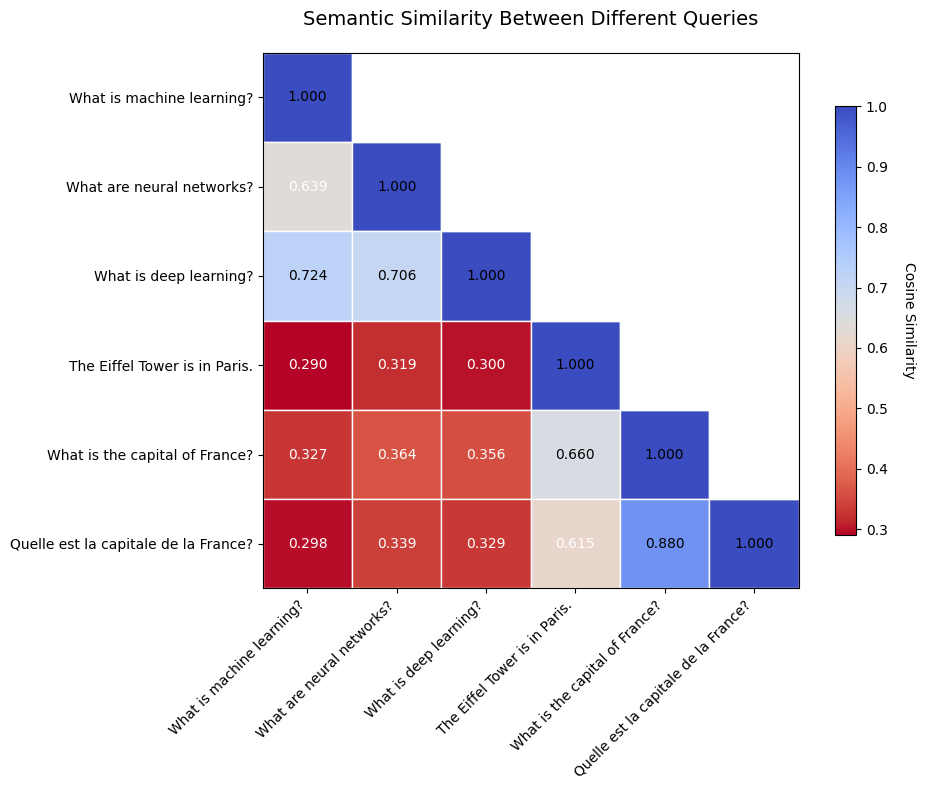

In [12]:

from utils import plot_triangular_similarity_heatmap

# Create labels for our queries
query_labels = [
    "What is machine learning?",
    "What are neural networks?",
    "What is deep learning?",
    "The Eiffel Tower is in Paris.",
    "What is the capital of France?",
    "Quelle est la capitale de la France?"
]

# Create the triangular similarity heatmap
fig, ax = plot_triangular_similarity_heatmap(
    wider_similarity, 
    query_labels, 
)

As the figure above shows, sentences with similar semantic meanings have higher cosine similarities. Embeddings for machine learning, deep learning, and neural networks all have reasonable cosine similarities, however have quite low cosine similarities when compared to the statement about the eiffel tower.

Embeddings (depending on the model) are capable of crossing language barriers too. The query "What is the capital of France?" has a high consine similarity with the embedding for the same statement translated to French "Quelle est la capitale de la France?"

This allows us to query text and databases in more dynamic ways. It allows a user to retrieve pieces of text that are related to their query not just exact matches like traditional keyword searches would return.

### Retrival by similarity search
Let's attempt to query the vectorstore using the built in similarity_search function, and return the three most relevant documents.

In [13]:
query = "What time is the walkthrough on Retrieval Augmented Generation?"

results = vectorstore.similarity_search(
    query, # Your query/question
    k=3 # Number of similar documents to retrieve (May also be seen as top_k)
)

results

[Document(id='92f76ee2-c163-4201-ac89-e3ab9abca3dd', metadata={'creationdate': '2025-09-02T12:44:48+00:00', 'producer': 'Skia/PDF m133', 'total_pages': 11, 'source': './rsecon_schedule.pdf', 'creator': 'Chromium', 'page': 9, 'title': 'Oxford Abstracts PDF Export', 'page_label': '10', 'moddate': '2025-09-02T12:44:48+00:00'}, page_content='Workshop\nInteractive Session\n13:30-15:00OC0.01\nSupporting DRI with Software Audits\nInteractive Session\n14:00-14:45OC1.05\nRetrieval Augmented Generation\nDeborah Udoh\nWalkthrough\nPresentation'),
 Document(id='c9176e74-672e-42d6-9adc-70c4d7909685', metadata={'page_label': '9', 'total_pages': 11, 'producer': 'Skia/PDF m133', 'creationdate': '2025-09-02T12:44:48+00:00', 'title': 'Oxford Abstracts PDF Export', 'moddate': '2025-09-02T12:44:48+00:00', 'source': './rsecon_schedule.pdf', 'creator': 'Chromium', 'page': 8}, page_content='Talk\nPresentation\n12:30-13:30The Oculus Atrium\nLunch\n13:30-14:00OC1.05\nEntity tagging Historical Texts with Deep L

### Formatting retrieved context

We can also format the retrieved documents into well formatted text that we can then pass to our LLM as context.

In [14]:
def format_docs(docs) -> str:
    """Format documents into a single string with metadata."""
    formatted_docs = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get('source', 'unknown')
        formatted_docs.append(f"Document {i} (Source: {source}):\n{doc.page_content}\n-----------------\n")
    return "\n".join(formatted_docs)

# Demonstrate formatting results
formatted_context = format_docs(results)
print(formatted_context)

Document 1 (Source: ./rsecon_schedule.pdf):
Workshop
Interactive Session
13:30-15:00OC0.01
Supporting DRI with Software Audits
Interactive Session
14:00-14:45OC1.05
Retrieval Augmented Generation
Deborah Udoh
Walkthrough
Presentation
-----------------

Document 2 (Source: ./rsecon_schedule.pdf):
Talk
Presentation
12:30-13:30The Oculus Atrium
Lunch
13:30-14:00OC1.05
Entity tagging Historical Texts with Deep Learning
Deborah Udoh
Walkthrough
Presentation
-----------------

Document 3 (Source: ./rsecon_schedule.pdf):
Interactive Session
13:30-14:45OC0.04
Geoscience SIG
Birds of a Feather
Interactive Session
13:30-14:45OC0.01
Hands-on AIRR Workshop Using Dawn
Workshop
Interactive Session
13:45-14:30OC0.03
-----------------



Hurrah! The first document contains the information about this session! We can now feed this in to our LLM as context to help it create informed and grounded responses.

## 5. LLM Integration (Ollama)

Now we'll set up flexible LLM integration that can work with different providers.

Using the `init_chat_model` helper function we can easily setup out LLMs similar to the `init_embeddings` function we used earlier.

In this walk through we will be using the open source llama models using the Ollama client.

You may need to install additional packages in order to use some of the LLM clients.

| Provider                | LangChain Package              |
|---------------------------|---------------------------------|
| openai                   | langchain-openai                |
| anthropic                | langchain-anthropic             |
| azure_openai             | langchain-openai                |
| azure_ai                 | langchain-azure-ai              |
| google_vertexai          | langchain-google-vertexai       |
| google_genai             | langchain-google-genai          |
| bedrock                  | langchain-aws                   |
| bedrock_converse         | langchain-aws                   |
| cohere                   | langchain-cohere                |
| fireworks                | langchain-fireworks             |
| together                 | langchain-together              |
| mistralai                | langchain-mistralai             |
| huggingface              | langchain-huggingface           |
| groq                     | langchain-groq                  |
| ollama                   | langchain-ollama                |
| google_anthropic_vertex  | langchain-google-vertexai       |
| deepseek                 | langchain-deepseek              |
| ibm                      | langchain-ibm                   |
| nvidia                   | langchain-nvidia-ai-endpoints   |
| xai                      | langchain-xai                   |
| perplexity               | langchain-perplexity            |

*Please refer to the provider-specific documentation when using these packages to ensure that you're passing correct additional kwargs*

Let's ask the model what RSECon25 is.

In [15]:
# Configure different LLM providers
llm = init_chat_model(model="gemma3:1b", model_provider='ollama')

response = llm.invoke('What is RSECon25?')
print(response.content)


RSECon25 is a highly significant and somewhat mysterious cybersecurity conference focused on the **Reconnaissance and Exploitation of Sensitive Information (RSE)**. It’s known for its deep dives into malware analysis, advanced exploitation techniques, and the murky world of information theft. Here’s a breakdown of what it is and why it's important:

**1. The Core Focus: Reconnaissance and Exploitation**

* **RSE** is a term coined by cybersecurity researchers to describe the process of gathering information about a target system, network, or organization. This isn't just about finding weaknesses; it's about systematically and rapidly building a detailed understanding of the target's infrastructure, configurations, and potential vulnerabilities.
* **Exploitation** is a crucial element. RSECon25 heavily emphasizes techniques to *actively* exploit vulnerabilities discovered during the reconnaissance phase. This often involves reverse engineering, fuzzing, and other advanced methods.

**2.

This llama model doesn't have any information about what RSECon25 is, which we would expect given that it has never been trained on that information. It is likely to respond with answers claiming it doesn't know, or it could hallucinate a response and invent what RSECon25 is.

Lets incorporate RAG into the LLM to reduce hallucinations and generate more grounded responses.

### Setting up prompt templates

Now we need to set up the prompt templates we can use with langchain when interacting with the LLM.

We can use this template to provide context to the LLM as well as our question/prompt. Here we will use the ChatPromptTemplate, this allows us to put system instructions with each message and then provide the LLM with question and context in a structured way.

Let's try this manually first.

In [16]:
from langchain_core.prompts.chat import ChatPromptTemplate

template = ChatPromptTemplate(input_variables=["question", "context"], messages=[
    ("system", "You are a helpful assistant that provides information about RSECon25 based on the provided context."),
    ("user", "{question}"),
    ("user", "{context}")
])

prompt = template.invoke({"question": "What is RSECon25?", "context": "RSECon25 is a conference focused on research software engineering."})
response = llm.invoke(prompt)
print(response.content)

Okay, you are correct! **RSECon25 is a conference focused on research software engineering.** 

Essentially, it’s a dedicated venue for researchers and practitioners to share their latest work on topics like:

*   **Software Design**
*   **Software Testing**
*   **Software Verification**
*   **Software Maintenance**
*   **Software Security**
*   **Human-Computer Interaction (HCI)** (often within the context of software engineering)

Do you want me to tell you more about it – perhaps about its history, attendees, or specific sessions?


Providing even a small amount of context to the LLM allows it to return better quality responses decreasing the the likelyhood of hallucinations.

In [17]:
question = "What time is the Retrieval Augmented Generation walkthough?"
retrieved_docs = vectorstore.similarity_search(question, k=1)
context = '\n'.join([doc.page_content for doc in retrieved_docs])
response = llm.invoke(template.invoke({"question": question, "context": context}))
print(context)

Workshop
Interactive Session
13:30-15:00OC0.01
Supporting DRI with Software Audits
Interactive Session
14:00-14:45OC1.05
Retrieval Augmented Generation
Deborah Udoh
Walkthrough
Presentation


In [18]:
print(response.content)

The Retrieval Augmented Generation walkthrough is scheduled for **13:30 - 15:00**.


# Advanced RAG: Agents, GraphRAG, LangSmith

The examples we have gone through in this walkthrough are a quick and simple example of RAG that is suitable for question and answer type scenarios that don't require any additional tools or processes.

There are a number of more advanced RAG techniques we'd like to introduce you to quickly.

## ReAct Agents

Reasoning Action (ReAct) Agents are a type of AI agent that combine chain of thought reasoning with external tool use. These kinda of agents enhance the ability of an LLM to process more complex tasks that may require decision making in agentic workflows.

ReAct agents use tools to perform actions and can be instructed how and when to use these tools.

Creating a ReAct agent in LangGraph is fairly straightforward, LangGraph has a useful helper function that allows you to create a ReAct agent with a single line of code.


In [39]:
from langchain_core.prompts.chat import HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

from agent.tools import TOOLS

llm = init_chat_model(model="gpt-oss:20b", model_provider="ollama")


def get_react_agent(llm, vectorstore=vectorstore, tools=TOOLS):
    """
    Create a ReAct agent with a language model and vector store.

    Args:
        llm: Language model instance
        vectorstore: Vector store instance

    Returns:
        agent: Configured ReAct agent
    """
    @tool
    def get_relevant_documents(query: str) -> list:
        """
        Useful for answering questions about the documents in the vector store. Input should be a fully formed question.
        """
        retriever = vectorstore.as_retriever()
        return retriever.invoke(query)

    prompt = "You are a helpful assistant for RSECon 2025. Answer the user's questions to the best of your ability."

    tools = tools + [get_relevant_documents]

    agent = create_react_agent(model=llm, tools=tools, prompt=prompt)

    return agent

In [40]:
agent = get_react_agent(llm=llm)

response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="What time is the retrieval augmented generation walkthrough?"
            )
        ]
    }
)

In [41]:
print(response["messages"][-1].content)

The **Retrieval Augmented Generation** walkthrough is scheduled as part of the interactive workshop session on **Monday, 8 September 2025** from **13:30 – 15:00**.


In [42]:
response = agent.invoke(
    {"messages": [HumanMessage(content="What is research software engineering?")]}
)

In [43]:
print(response["messages"][-1].content)

**Research Software Engineering (RSE)** is a discipline that applies software‑engineering principles to the development, maintenance, and reuse of software created for research.  
Key points:

| Aspect | What it means for RSE |
|--------|-----------------------|
| **Purpose** | Software is written primarily to support scientific investigations, experiments, or data analysis. |
| **Scope** | Goes beyond writing code: it includes design, testing, documentation, reproducibility, version control, and long‑term maintenance. |
| **Goal** | Make research software robust, reusable, and reproducible—so that other scientists can build on it, verify results, and extend it. |
| **Community** | RSEs often work in academia, national labs, or industry R&D, collaborating with scientists, engineers, and sometimes policy makers. |
| **Open‑Science Connection** | RSE practice encourages open source licensing, sharing of code, and transparent workflows, aligning with open‑science principles. |

In short, 